# Слияние нейросетей без обучения — механика на контролируемом стенде

**Что демонстрирует этот ноутбук (полностью воспроизводимо, CPU, ~1 минута):**

1. **Перестановочная симметрия — главное препятствие.** Две функционально *идентичные* сети, отличающиеся лишь порядком скрытых нейронов, нельзя слить наивным усреднением весов.
2. **Это лечится численно, без обучения и дистилляции** — выравниванием нейронов по корреляции активаций (венгерский алгоритм).
3. **Барьер потерь и общая инициализация.** Две независимо обученные сети при усреднении дают «барьер»; общая инициализация его убирает — эмпирическая иллюстрация **Linear Mode Connectivity** (Frankle et al., 2020).

Контролируемый стенд, на котором изолированно видно ядро всей области model merging. Семантическая часть (king/queen, concept-survival) — в `02_kingqueen_real_models.ipynb`.

> Baseline → метод → сравнение; все случайности зафиксированы seed'ами.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cpu")  # стенд маленький; CPU детерминированнее
print("torch", torch.__version__, "| device:", device)

torch 2.12.0 | device: cpu


## 1. Данные и модель

Одна регрессионная задача `y = sin(1.5x) + 0.3x`. Сеть: один скрытый слой, `tanh`,
ширина 128. Инициализация и выборки данных детерминированы seed'ами.

In [2]:
def make_data(seed, n=600):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-3, 3, (n, 1)).astype("float32")
    y = (np.sin(1.5 * x) + 0.3 * x).astype("float32")
    return torch.from_numpy(x), torch.from_numpy(y)

class MLP(nn.Module):
    def __init__(self, hidden=128, seed=0):
        super().__init__()
        g = torch.Generator().manual_seed(seed)
        self.fc1 = nn.Linear(1, hidden)
        self.fc2 = nn.Linear(hidden, 1)
        for lin in (self.fc1, self.fc2):
            nn.init.xavier_uniform_(lin.weight, generator=g)
            nn.init.zeros_(lin.bias)
    def hidden(self, x):
        return torch.tanh(self.fc1(x))
    def forward(self, x):
        return self.fc2(self.hidden(x))

def train(model, x, y, epochs=3000, lr=0.01):
    opt = torch.optim.Adam(model.parameters(), lr=lr); lossf = nn.MSELoss()
    for _ in range(epochs):
        opt.zero_grad(); loss = lossf(model(x), y); loss.backward(); opt.step()
    return model

def mse(model, x, y):
    with torch.no_grad():
        return float(nn.MSELoss()(model(x), y))

def clone_like(net):
    m = MLP(); m.load_state_dict(net.state_dict()); return m

def average_models(a, b, w=0.5):
    out = clone_like(a); sd_a, sd_b = a.state_dict(), b.state_dict()
    out.load_state_dict({k: w * sd_a[k] + (1 - w) * sd_b[k] for k in sd_a})
    return out

def permute_hidden(net, perm):
    # Возвращает функционально-идентичную сеть с переставленными нейронами
    out = clone_like(net); sd = net.state_dict(); nd = dict(sd)
    nd["fc1.weight"] = sd["fc1.weight"][perm, :]
    nd["fc1.bias"]   = sd["fc1.bias"][perm]
    nd["fc2.weight"] = sd["fc2.weight"][:, perm]
    out.load_state_dict(nd); return out

def align_by_activations(ref, other, x_cal):
    # Перестановка нейронов other под ref по корреляции активаций (без обучения)
    with torch.no_grad():
        Ha = ref.hidden(x_cal).numpy(); Hb = other.hidden(x_cal).numpy()
    Ha = (Ha - Ha.mean(0)) / (Ha.std(0) + 1e-8)
    Hb = (Hb - Hb.mean(0)) / (Hb.std(0) + 1e-8)
    corr = (Ha.T @ Hb) / Ha.shape[0]            # ref x other
    row, col = linear_sum_assignment(-corr)     # максимум суммарной корреляции
    return permute_hidden(other, col), corr

x_te, y_te = make_data(100)
print("данные и модель готовы")

данные и модель готовы


## 2. Часть A. Перестановочная симметрия — главное препятствие

Обучим сеть `R`, затем создадим её копию `R_perm` со **случайно переставленными**
скрытыми нейронами. `R_perm` — это *в точности та же функция* (перестановка нейронов
не меняет выход). Но их веса лежат по-разному. Попробуем наивно усреднить.

In [3]:
x_tr, y_tr = make_data(1)
R = train(MLP(seed=10), x_tr, y_tr)

rng = np.random.default_rng(7)
perm = rng.permutation(128)
R_perm = permute_hidden(R, perm)

same = np.allclose(R(x_te).detach().numpy(), R_perm(x_te).detach().numpy(), atol=1e-5)
print("R и R_perm — одна и та же функция?", same)
print(f"MSE R              : {mse(R, x_te, y_te):.5f}")
print(f"MSE наивного avg(R, R_perm): {mse(average_models(R, R_perm), x_te, y_te):.5f}  <- сломано!")

R и R_perm — одна и та же функция? True
MSE R              : 0.00046
MSE наивного avg(R, R_perm): 0.50966  <- сломано!


**Вывод части A (1):** усреднение двух *идентичных по функции* сетей даёт мусор —
значит, дело именно в **рассогласовании порядка нейронов**, а не в различии задач.
Посмотрим на матрицу корреляций активаций.

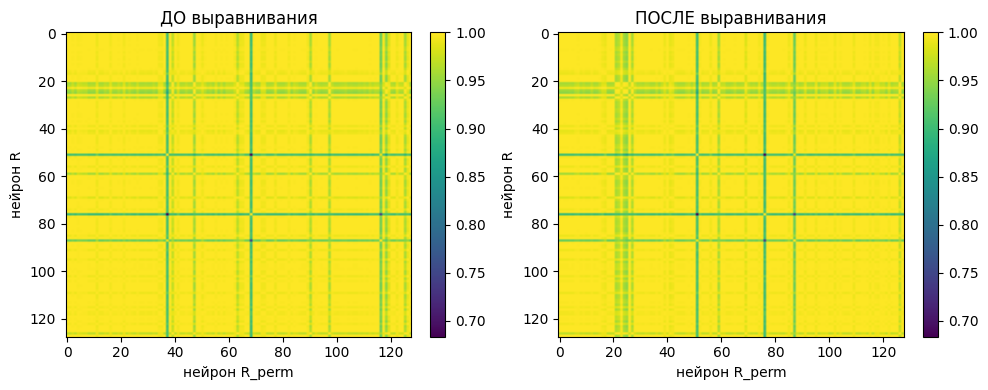

In [4]:
x_cal = torch.cat([make_data(1)[0], make_data(2)[0]])
_, corr_before = align_by_activations(R, R_perm, x_cal)
R_perm_aligned, _ = align_by_activations(R, R_perm, x_cal)
_, corr_after = align_by_activations(R, R_perm_aligned, x_cal)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, C, t in [(ax[0], corr_before, "ДО выравнивания"),
                (ax[1], corr_after,  "ПОСЛЕ выравнивания")]:
    im = a.imshow(np.abs(C), cmap="viridis", aspect="auto")
    a.set_title(t); a.set_xlabel("нейрон R_perm"); a.set_ylabel("нейрон R")
    fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

In [5]:
# Выравнивание восстанавливает перестановку -> слияние становится идеальным
print("R_perm_aligned == R по функции?",
      np.allclose(R_perm_aligned(x_te).detach().numpy(),
                  R_perm(x_te).detach().numpy(), atol=1e-4))
print(f"MSE наивного avg(R, R_perm)          : {mse(average_models(R, R_perm), x_te, y_te):.5f}")
print(f"MSE avg(R, ВЫРОВНЕННОГО R_perm) [наш]: {mse(average_models(R, R_perm_aligned), x_te, y_te):.5f}  <- починено")

R_perm_aligned == R по функции? True
MSE наивного avg(R, R_perm)          : 0.50966
MSE avg(R, ВЫРОВНЕННОГО R_perm) [наш]: 0.00046  <- починено


**Вывод части A (2):** численное выравнивание по активациям (венгерский алгоритм,
**без единого шага обучения**) восстанавливает соответствие нейронов — и усреднение
снова даёт исходную функцию. Это изолированное доказательство механизма: *препятствие —
перестановочная симметрия, лечится численным выравниванием.*

## 3. Часть B. Барьер потерь и роль общей инициализации (LMC)

Теперь две **независимо обученные** сети на той же задаче (разные инициализация и
выборки). При линейной интерполяции весов между ними возникает **барьер потерь**.
А если обе стартуют из **одной** инициализации — барьер исчезает (Linear Mode
Connectivity, Frankle 2020).

In [6]:
# Разная инициализация + разные данные
xa, ya = make_data(1); xb, yb = make_data(2)
A = train(MLP(seed=10), xa, ya)
B = train(MLP(seed=20), xb, yb)

# Общая инициализация (один seed), разные данные
As = train(MLP(seed=99), xa, ya)
Bs = train(MLP(seed=99), xb, yb)

def interp_path(a, b, n=11):
    ts = np.linspace(0, 1, n); out = []
    for t in ts:
        out.append(mse(average_models(a, b, w=1 - t), x_te, y_te))
    return ts, out

t1, p_diff   = interp_path(A, B)
t2, p_shared = interp_path(As, Bs)
print(f"barrier (разная иниц.)  в середине пути: {p_diff[5]:.4f}")
print(f"barrier (общая иниц.)   в середине пути: {p_shared[5]:.4f}")

barrier (разная иниц.)  в середине пути: 0.4823
barrier (общая иниц.)   в середине пути: 0.0005


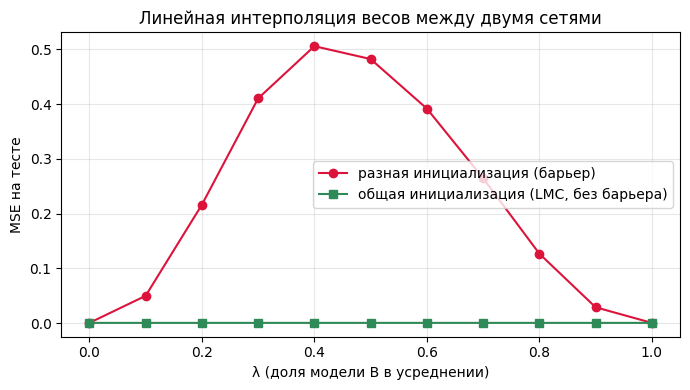

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(t1, p_diff,   "o-", c="crimson",   label="разная инициализация (барьер)")
plt.plot(t2, p_shared, "s-", c="seagreen",  label="общая инициализация (LMC, без барьера)")
plt.xlabel("λ (доля модели B в усреднении)"); plt.ylabel("MSE на тесте")
plt.title("Линейная интерполяция весов между двумя сетями")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 4. Сводка результатов

In [8]:
rows = [
    {"сценарий": "одиночная сеть R (ориентир)",                         "MSE": round(mse(R, x_te, y_te), 5)},
    {"сценарий": "наив. avg(R, R_perm) — идентичные функции",           "MSE": round(mse(average_models(R, R_perm), x_te, y_te), 5)},
    {"сценарий": "avg(R, выровненного R_perm) — наш метод",             "MSE": round(mse(average_models(R, R_perm_aligned), x_te, y_te), 5)},
    {"сценарий": "наив. avg двух сетей (разная иниц.) — барьер",        "MSE": round(p_diff[5], 5)},
    {"сценарий": "наив. avg двух сетей (общая иниц., LMC)",             "MSE": round(p_shared[5], 5)},
]
pd.DataFrame(rows)

,сценарий,MSE
0,одиночная сеть R (ориентир),0.00046
1,"наив. avg(R, R_perm) — идентичные функции",0.50966
2,"avg(R, выровненного R_perm) — наш метод",0.00046
3,наив. avg двух сетей (разная иниц.) — барьер,0.48234
4,"наив. avg двух сетей (общая иниц., LMC)",0.00046


## 5. Выводы и связь с новизной

- **Перестановочная симметрия** скрытых нейронов — фундаментальное препятствие слияния весов: даже две *идентичные* функции не усредняются (часть A).
- Препятствие снимается **численным выравниванием по активациям** — без обучения и дистилляции (часть A).
- Для независимо обученных сетей возникает **барьер потерь**; **общая инициализация** его убирает (LMC, часть B).

**Честное ограничение стенда:** выравнивание *идентичной* (переставленной) сети восстанавливается точно; выравнивание двух *по-разному обученных* решений сложнее (неоднозначность знака `tanh`-признаков, требуется бóльшая ширина / обработка знака — как в полном Git Re-Basin). Здесь мы изолируем механизм, а не воспроизводим Re-Basin целиком.

**Связь с вкладом работы:** существующее выравнивание (Git Re-Basin, ZipIt, CCA-Merge) использует *обобщённую* корреляцию активаций. Наш вклад — **Concept-Anchored Merging**: сделать целью слияния сохранение *конкретного именованного концепта* и измерять его **выживаемость**. Реальная демонстрация на king/queen — в `02_kingqueen_real_models.ipynb`.